In [1]:
import numpy as np
import matplotlib.pyplot as plt

from noninteracting import KagomeNagaosa, KagomeStaggerFlux, KagomeKaneMeleSOC
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from channels import ChannelDecomposer

# Noninteracting Model

In [2]:
# choose one model
model = KagomeKaneMeleSOC(
    parameters={"t": 1.0, "l1": 0, "l2":0},
    spin=True,
    B=0.0,
)

print("model class =", type(model).__name__)
print("parameters =", model.parameters)
print("spin =", model.spin)

print("\nreal-space bond vectors:")
print("delta1 =", model.delta1)
print("delta2 =", model.delta2)
print("delta3 =", model.delta3)

print("\nreciprocal vectors:")
print("b1 =", model.b1)
print("b2 =", model.b2)

model class = KagomeKaneMeleSOC
parameters = {'t': 1.0, 'l1': 0, 'l2': 0}
spin = True

real-space bond vectors:
delta1 = [0.5       0.8660254]
delta2 = [ 0.5       -0.8660254]
delta3 = [-1.  0.]

reciprocal vectors:
b1 = [0.         3.62759873]
b2 = [3.14159265 1.81379936]


In [3]:
kx, ky = 0.2, 0.3
H = model.Hk(kx, ky)
evals, evecs = np.linalg.eigh(H)

print("H shape =", H.shape)
print("\nH(k) =")
print(np.round(H, 6))

print("\neigenvalues =")
print(np.round(evals, 6))

print("\nfirst eigenvector =")
print(np.round(evecs[:, 0], 6))

H shape = (6, 6)

H(k) =
[[ 0.      +0.j -1.871929+0.j -1.974516+0.j  0.      +0.j  0.      +0.j
   0.      +0.j]
 [-1.871929+0.j  0.      +0.j -1.960133+0.j  0.      +0.j  0.      +0.j
   0.      +0.j]
 [-1.974516+0.j -1.960133+0.j  0.      +0.j  0.      +0.j  0.      +0.j
   0.      +0.j]
 [ 0.      +0.j  0.      +0.j  0.      +0.j  0.      +0.j -1.871929+0.j
  -1.974516+0.j]
 [ 0.      +0.j  0.      +0.j  0.      +0.j -1.871929+0.j  0.      +0.j
  -1.960133+0.j]
 [ 0.      +0.j  0.      +0.j  0.      +0.j -1.974516+0.j -1.960133+0.j
   0.      +0.j]]

eigenvalues =
[-3.871403 -3.871403  1.871403  1.871403  2.        2.      ]

first eigenvector =
[0.574936+0.j 0.573474+0.j 0.583589+0.j 0.      +0.j 0.      +0.j
 0.      +0.j]


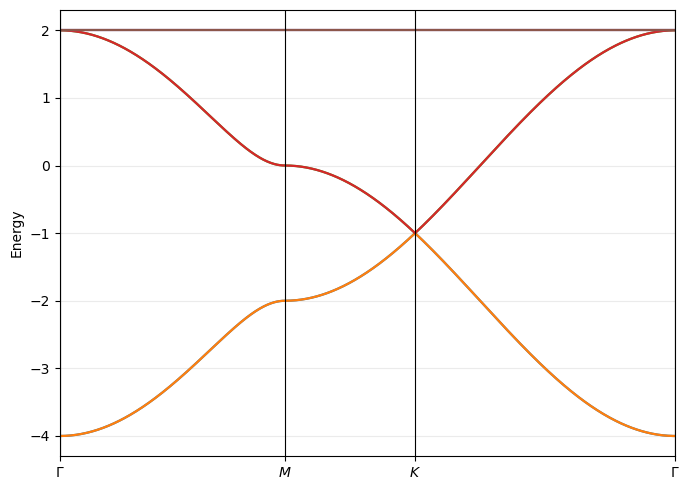

In [4]:
# ========= reciprocal vectors =========
b1 = np.array(model.b1, dtype=float)
b2 = np.array(model.b2, dtype=float)

# ========= high-symmetry points =========
Gamma = np.array([0.0, 0.0])
M = 0.5 * b2
K = (2.0 * b2 - b1) / 3.0

labels = [r"$\Gamma$", r"$M$", r"$K$", r"$\Gamma$"]
points = [Gamma, M, K, Gamma]

# ========= build path =========
def interpolate_path(points, n_per_segment=200):
    ks = []
    x = []
    node_positions = [0.0]

    total_len = 0.0
    for i in range(len(points) - 1):
        p0 = np.array(points[i], dtype=float)
        p1 = np.array(points[i + 1], dtype=float)

        seg = p1 - p0
        seg_len = np.linalg.norm(seg)

        for j in range(n_per_segment):
            t = j / n_per_segment
            k = (1 - t) * p0 + t * p1
            ks.append(k)
            x.append(total_len + t * seg_len)

        total_len += seg_len
        node_positions.append(total_len)

    ks.append(np.array(points[-1], dtype=float))
    x.append(total_len)

    return np.array(ks), np.array(x), np.array(node_positions)

ks, x, node_positions = interpolate_path(points, n_per_segment=250)

# ========= compute bands =========
nbands = model.Hk(0.0, 0.0).shape[0]   # spinful => 6
E = np.zeros((len(ks), nbands))

for i, k in enumerate(ks):
    evals = np.linalg.eigvalsh(model.Hk(k[0], k[1]))
    E[i, :] = evals

# ========= plot =========
plt.figure(figsize=(7, 5))

for n in range(nbands):
    plt.plot(x, E[:, n], linewidth=1.6)

for xpos in node_positions:
    plt.axvline(x=xpos, color="k", linewidth=0.8)

plt.xticks(node_positions, labels)
plt.ylabel("Energy")
plt.xlim(x[0], x[-1])
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Patching

In [5]:
patcher_first_block = FSPatcher(
    model=model,
    band_index=1,              # local band index inside the first 3x3 block
    filling=5/12,
    Npatch=24,
    grid_size=220,
    orbital_slice=slice(0, 3),
    verbose=False,
)

patcher_last_block = FSPatcher(
    model=model,
    band_index=1,              # local band index inside the last 3x3 block
    filling=5/12,
    Npatch=24,
    grid_size=220,
    orbital_slice=slice(3, 6),
    verbose=False,
)

print("patcher_first_block.orbital_slice =", patcher_first_block.orbital_slice)
print("patcher_last_block.orbital_slice  =", patcher_last_block.orbital_slice)
print("local band index =", patcher_first_block.band_index)

# patchset_first = patcher_first_block.build()
# print(patchset_first.gauge_method)

patcher_first_block.orbital_slice = slice(0, 3, None)
patcher_last_block.orbital_slice  = slice(3, 6, None)
local band index = 1


In [6]:
patchset_first = patcher_first_block.build()
patchset_last = patcher_last_block.build()

print("first block patchset Npatch =", patchset_first.Npatch)
print("last  block patchset Npatch =", patchset_last.Npatch)

print("\nfirst block eigvec shape =", patchset_first.patches[0].eigvec.shape)
print("last  block eigvec shape =", patchset_last.patches[0].eigvec.shape)

print("\nfirst block first eigvec =")
print(np.round(patchset_first.patches[0].eigvec, 6))

print("\nlast block first eigvec =")
print(np.round(patchset_last.patches[0].eigvec, 6))

first block patchset Npatch = 24
last  block patchset Npatch = 24

first block eigvec shape = (3,)
last  block eigvec shape = (3,)

first block first eigvec =
[ 0.999842+0.j  0.      +0.j -0.017788+0.j]

last block first eigvec =
[ 0.999842+0.j  0.      +0.j -0.017788+0.j]


In [7]:
p0 = patchset_first.patches[0]
print("patch id =", p0.patch_id)
print("k_cart =", p0.k_cart)
print("k_red =", p0.k_red)
print("energy =", p0.energy)
print("vF =", p0.vF)
print("vF_norm =", p0.vF_norm)
print("eigvec =", np.round(p0.eigvec, 6))
print("orbital_weight =", np.round(p0.orbital_weight, 6))

patch id = 0
k_cart = [-0.01778854  1.80352915]
k_red = [0.5        0.99433773]
energy = -5.882885954219735e-17
vF = [ 0.03556958 -0.06160831]
vF_norm = 0.07113915436047161
eigvec = [ 0.999842+0.j  0.      +0.j -0.017788+0.j]
orbital_weight = [9.99684e-01 0.00000e+00 3.16000e-04]


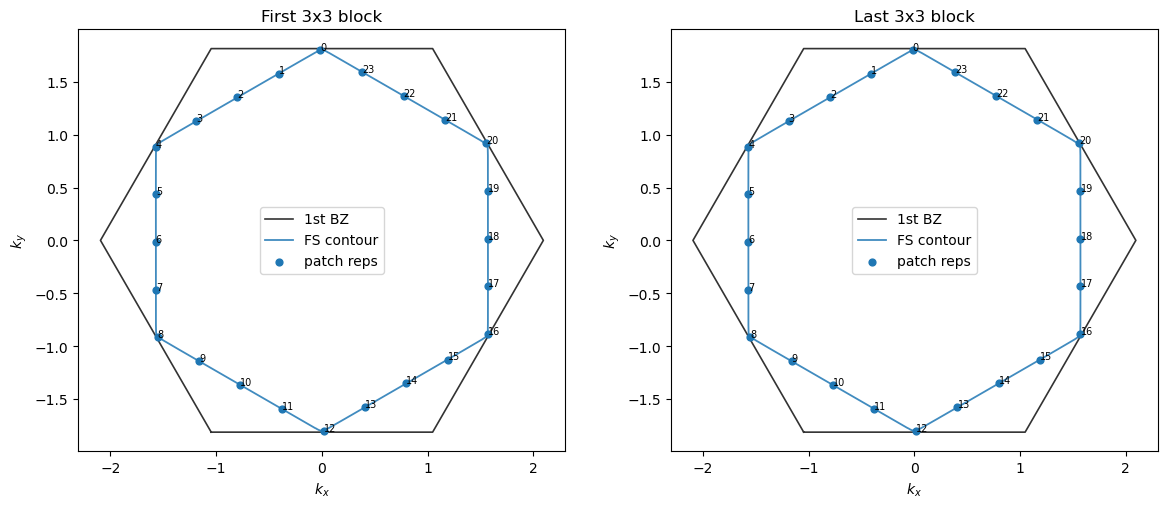

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_patchset(patchset_first, ax=axes[0], show_contour=True, show_velocity=False, show_bz=True)
axes[0].set_title("First 3x3 block")

plot_patchset(patchset_last, ax=axes[1], show_contour=True, show_velocity=False, show_bz=True)
axes[1].set_title("Last 3x3 block")

for ax in axes:
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [9]:
patchsets = {
    "up": patchset_first,
    "dn": patchset_last,
}

print("patchsets keys =", list(patchsets.keys()))
print("up Npatch =", patchsets["up"].Npatch)
print("dn Npatch =", patchsets["dn"].Npatch)

print("\nup first eigvec shape =", patchsets["up"].patches[0].eigvec.shape)
print("dn first eigvec shape =", patchsets["dn"].patches[0].eigvec.shape)

patchsets keys = ['up', 'dn']
up Npatch = 24
dn Npatch = 24

up first eigvec shape = (3,)
dn first eigvec shape = (3,)


# Vertex Interaction

In [10]:
from interaction import BareExtendedHubbard

interaction = BareExtendedHubbard.from_kagome_model(
    model,
    U=4.0,
    V=1.5,
)

print(interaction)
print("\ndelta1 =", interaction.delta1)
print("delta2 =", interaction.delta2)
print("delta3 =", interaction.delta3)

BareExtendedHubbard(U=4.0, V=1.5, delta1=array([0.5      , 0.8660254]), delta2=array([ 0.5      , -0.8660254]), delta3=array([-1.,  0.]))

delta1 = [0.5       0.8660254]
delta2 = [ 0.5       -0.8660254]
delta3 = [-1.  0.]


In [11]:
q = np.array([0.2, 0.3])

W_udud = interaction.orbital_interaction_matrix(q, 'up', 'dn', 'up', 'dn')
W_uuuu = interaction.orbital_interaction_matrix(q, 'up', 'up', 'up', 'up')
W_flip = interaction.orbital_interaction_matrix(q, 'up', 'dn', 'dn', 'up')

print("W_udud =")
print(np.round(W_udud, 6))

print("\nW_uuuu =")
print(np.round(W_uuuu, 6))

print("\nW_flip =")
print(np.round(W_flip, 6))

W_udud =
[[4.      +0.j 2.807894+0.j 2.961774+0.j]
 [2.807894+0.j 4.      +0.j 2.9402  +0.j]
 [2.961774+0.j 2.9402  +0.j 4.      +0.j]]

W_uuuu =
[[0.      +0.j 2.807894+0.j 2.961774+0.j]
 [2.807894+0.j 0.      +0.j 2.9402  +0.j]
 [2.961774+0.j 2.9402  +0.j 0.      +0.j]]

W_flip =
[[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]]


In [12]:
p1, p2, p3, p4 = 0, 1, 0, 1

gamma_dir = interaction.patch_vertex(
    patchsets,
    p1, 'up',
    p2, 'dn',
    p3, 'up',
    p4, 'dn',
    antisym=False,
)

gamma_as = interaction.patch_vertex(
    patchsets,
    p1, 'up',
    p2, 'dn',
    p3, 'up',
    p4, 'dn',
    antisym=True,
)

print("direct vertex =", gamma_dir)
print("antisymmetrized vertex =", gamma_as)

direct vertex = (3.8417224497025524+0j)
antisymmetrized vertex = (3.8417224497025524+0j)


In [13]:
gamma_1234 = interaction.patch_vertex(
    patchsets,
    0, 'up',
    1, 'dn',
    0, 'up',
    1, 'dn',
    antisym=True,
)

gamma_1243 = interaction.patch_vertex(
    patchsets,
    0, 'up',
    1, 'dn',
    1, 'dn',
    0, 'up',
    antisym=True,
)

gamma_2134 = interaction.patch_vertex(
    patchsets,
    1, 'dn',
    0, 'up',
    0, 'up',
    1, 'dn',
    antisym=True,
)

print("gamma_1234 =", gamma_1234)
print("gamma_1243 =", gamma_1243)
print("gamma_2134 =", gamma_2134)

print("\noutgoing antisym residual =", gamma_1234 + gamma_1243)
print("incoming antisym residual =", gamma_1234 + gamma_2134)

gamma_1234 = (3.8417224497025524+0j)
gamma_1243 = (-3.8417224497025524+0j)
gamma_2134 = (-3.8417224497025524+0j)

outgoing antisym residual = 0j
incoming antisym residual = 0j


In [14]:
gamma_uu_dir = interaction.patch_vertex(
    patchsets,
    0, 'up',
    1, 'up',
    0, 'up',
    1, 'up',
    antisym=False,
)

gamma_uu_as = interaction.patch_vertex(
    patchsets,
    0, 'up',
    1, 'up',
    0, 'up',
    1, 'up',
    antisym=True,
)

print("same-spin direct vertex =", gamma_uu_dir)
print("same-spin antisym vertex =", gamma_uu_as)

same-spin direct vertex = (0.47483265089234317+0j)
same-spin antisym vertex = (0.43590548038273885+0j)


In [15]:
tensor_udud = interaction.patch_tensor(
    patchsets,
    'up', 'dn', 'up', 'dn',
    antisym=True,
)

print("tensor_udud shape =", tensor_udud.shape)
print("tensor_udud[0,1,0,1] =", tensor_udud[0,1,0,1])
print("tensor_udud[1,0,0,1] =", tensor_udud[1,0,0,1])
print("tensor_udud[0,1,1,0] =", tensor_udud[0,1,1,0])

tensor_udud shape = (24, 24, 24, 24)
tensor_udud[0,1,0,1] = (3.8417224497025524+0j)
tensor_udud[1,0,0,1] = (3.405816969319813+0j)
tensor_udud[0,1,1,0] = (3.405816969319813+0j)


# Channel Decomposition

In [16]:
# hard reset
patchsets = {
    "up": patchset_first,
    "dn": patchset_last,
}

print("up eigvec shape =", patchsets["up"].patches[0].eigvec.shape)
print("dn eigvec shape =", patchsets["dn"].patches[0].eigvec.shape)

assert patchsets["up"].patches[0].eigvec.shape == (3,)
assert patchsets["dn"].patches[0].eigvec.shape == (3,)

up eigvec shape = (3,)
dn eigvec shape = (3,)


In [17]:
import importlib
import channels
importlib.reload(channels)
from channels import ChannelDecomposer

decomp = ChannelDecomposer(interaction, patchsets)
Q = np.array([0.2, 0.3])

print("ChannelDecomposer constructed.")

ChannelDecomposer constructed.


In [18]:
for spin in ['up', 'dn']:
    qm_idx, qm_res = decomp.shifted_patch_map(spin, Q, mode='Q_minus_k')
    kp_idx, kp_res = decomp.shifted_patch_map(spin, Q, mode='k_plus_Q')
    km_idx, km_res = decomp.shifted_patch_map(spin, Q, mode='k_minus_Q')

    print(f"\nspin = {spin}")
    print("Q-k partner idx =", qm_idx)
    print("Q-k residual    =", np.round(qm_res, 6))
    print("k+Q partner idx =", kp_idx)
    print("k+Q residual    =", np.round(kp_res, 6))
    print("k-Q partner idx =", km_idx)
    print("k-Q residual    =", np.round(km_res, 6))


spin = up
Q-k partner idx = [13 14 15 16  3 18 19  8  7  7 22 13 13  0  1  2  3  4  5  6  7  9 10 11]
Q-k residual    = [0.203994 0.203669 0.20367  0.190736 0.206972 0.249683 0.249683 0.223198
 0.223198 0.230397 0.360457 0.232195 0.230641 0.203994 0.203669 0.20367
 0.190736 0.249954 0.249683 0.249683 0.262715 0.360457 0.360457 0.360457]
k+Q partner idx = [13  0  1  2  3  4  5  6  7  9 10 11 13 14 15 16  3 18 19  8  7  7 22 13]
k+Q residual    = [0.231772 0.204983 0.204655 0.204656 0.190218 0.250908 0.250635 0.250635
 0.264432 0.360555 0.360555 0.360555 0.20497  0.204655 0.204656 0.191786
 0.206178 0.250635 0.250635 0.224119 0.224914 0.228819 0.360555 0.233747]
k-Q partner idx = [ 1  2  3  4 15  6  7 20 19 19 10  1  1 12 13 14 15 16 17 18 19 21 22 23]
k-Q residual    = [0.204983 0.204655 0.204656 0.190218 0.207788 0.250635 0.250635 0.224914
 0.224119 0.229736 0.360555 0.231707 0.231787 0.20497  0.204655 0.204656
 0.191786 0.25094  0.250635 0.250635 0.263616 0.360555 0.360555 0.360555]


In [19]:
K_ud_ud = decomp.pp_kernel(Q, incoming_spins=('up', 'dn'), outgoing_spins=('up', 'dn'))
print("K_ud_ud ok, shape =", K_ud_ud.matrix.shape)

K_ud_du = decomp.pp_kernel(Q, incoming_spins=('up', 'dn'), outgoing_spins=('dn', 'up'))
print("K_ud_du ok, shape =", K_ud_du.matrix.shape)

K_du_ud = decomp.pp_kernel(Q, incoming_spins=('dn', 'up'), outgoing_spins=('up', 'dn'))
print("K_du_ud ok, shape =", K_du_ud.matrix.shape)

K_du_du = decomp.pp_kernel(Q, incoming_spins=('dn', 'up'), outgoing_spins=('dn', 'up'))
print("K_du_du ok, shape =", K_du_du.matrix.shape)

K_uu = decomp.pp_kernel(Q, incoming_spins=('up', 'up'), outgoing_spins=('up', 'up'))
print("K_uu ok, shape =", K_uu.matrix.shape)

K_dd = decomp.pp_kernel(Q, incoming_spins=('dn', 'dn'), outgoing_spins=('dn', 'dn'))
print("K_dd ok, shape =", K_dd.matrix.shape)

K_ud_ud ok, shape = (24, 24)
K_ud_du ok, shape = (24, 24)
K_du_ud ok, shape = (24, 24)
K_du_du ok, shape = (24, 24)
K_uu ok, shape = (24, 24)
K_dd ok, shape = (24, 24)


In [20]:
K_phd_uu = decomp.ph_direct_kernel(Q, incoming_spins=('up', 'up'), outgoing_spins=('up', 'up'))
print("K_phd_uu ok, shape =", K_phd_uu.matrix.shape)

K_phd_dd = decomp.ph_direct_kernel(Q, incoming_spins=('dn', 'dn'), outgoing_spins=('dn', 'dn'))
print("K_phd_dd ok, shape =", K_phd_dd.matrix.shape)

K_phc_uu = decomp.ph_crossed_kernel(Q, incoming_spins=('up', 'up'), outgoing_spins=('up', 'up'))
print("K_phc_uu ok, shape =", K_phc_uu.matrix.shape)

K_phc_dd = decomp.ph_crossed_kernel(Q, incoming_spins=('dn', 'dn'), outgoing_spins=('dn', 'dn'))
print("K_phc_dd ok, shape =", K_phc_dd.matrix.shape)

K_phd_uu ok, shape = (24, 24)
K_phd_dd ok, shape = (24, 24)
K_phc_uu ok, shape = (24, 24)
K_phc_dd ok, shape = (24, 24)


In [21]:
for name, kernel in {
    "K_ud_ud": K_ud_ud,
    "K_uu": K_uu,
    "K_dd": K_dd,
    "K_phd_uu": K_phd_uu,
    "K_phc_uu": K_phc_uu,
}.items():
    print("\n" + "=" * 72)
    print(name)
    for k, v in decomp.summarize(kernel).items():
        print(f"{k:28s}: {v}")


K_ud_ud
Npatch                      : 24.0
max_patch_match_residual    : 0.3604566002750374
mean_patch_match_residual   : 0.27372766697134937
hermitian_residual          : 8.881784197001252e-16
largest_abs_eigenvalue      : 28.45636503628564
largest_real_part           : 28.45636503628564

K_uu
Npatch                      : 24.0
max_patch_match_residual    : 0.3604566002750374
mean_patch_match_residual   : 0.27372766697134937
hermitian_residual          : 1.5872146428490939
largest_abs_eigenvalue      : 12.112088488961332
largest_real_part           : 12.112088488961332

K_dd
Npatch                      : 24.0
max_patch_match_residual    : 0.3604566002750374
mean_patch_match_residual   : 0.27372766697134937
hermitian_residual          : 1.5872146428490939
largest_abs_eigenvalue      : 12.112088488961332
largest_real_part           : 12.112088488961332

K_phd_uu
Npatch                      : 24.0
max_patch_match_residual    : 0.360555127546399
mean_patch_match_residual   : 0.2743822306

In [22]:
pp_combined = decomp.pp_singlet_triplet_sz0(Q)
ph_combined = decomp.ph_charge_spin_longitudinal(Q)

print("pp singlet (Sz=0) shape =", pp_combined["singlet_sz0"].matrix.shape)
print("pp triplet (Sz=0) shape =", pp_combined["triplet_sz0"].matrix.shape)
print("ph charge shape =", ph_combined["charge"].matrix.shape)
print("ph spin shape =", ph_combined["spin"].matrix.shape)

pp singlet (Sz=0) shape = (24, 24)
pp triplet (Sz=0) shape = (24, 24)
ph charge shape = (24, 24)
ph spin shape = (24, 24)


In [23]:
for name, kernel in {
    'pp_singlet_sz0': pp_combined['singlet_sz0'],
    'pp_triplet_sz0': pp_combined['triplet_sz0'],
    'ph_charge': ph_combined['charge'],
    'ph_spin': ph_combined['spin'],
}.items():
    vals, vecs = kernel.eig(sort_by='abs')
    print("\n" + "-" * 72)
    print(name)
    print("leading eigenvalue =", vals[0])
    print("leading eigenvector =", np.round(vecs[:, 0], 6))


------------------------------------------------------------------------
pp_singlet_sz0
leading eigenvalue = (57.08278426478348+8.881630432397185e-17j)
leading eigenvector = [ 0.205828+0.j  0.205732+0.j  0.205563+0.j  0.206248-0.j -0.196507+0.j
  0.205803-0.j  0.206238-0.j -0.199347+0.j -0.199347+0.j -0.181388+0.j
  0.213741+0.j -0.181612-0.j -0.198598-0.j  0.205828+0.j  0.205732+0.j
  0.205563+0.j  0.206248-0.j  0.205463-0.j  0.205803-0.j  0.206238-0.j
  0.207056-0.j  0.21399 +0.j  0.213741+0.j  0.213498+0.j]

------------------------------------------------------------------------
pp_triplet_sz0
leading eigenvalue = (12.112088488961334-2.090211392485275e-31j)
leading eigenvector = [-2.04327e-01-0.j -4.62829e-01+0.j -4.52718e-01+0.j -1.84705e-01+0.j
  1.00000e-05-0.j -4.46080e-02+0.j -4.36260e-02+0.j -3.08700e-03+0.j
  3.08700e-03-0.j  3.09030e-02-0.j -1.26610e-02+0.j  2.84100e-03-0.j
 -8.30000e-05+0.j  2.04327e-01+0.j  4.62829e-01+0.j  4.52718e-01-0.j
  1.84705e-01-0.j  1.97040e-02-

# Order Diagnosis